# ================================================================
# Phase 7-C — Calibration Robustness and Leave-One-Real-Out Validation
# ================================================================

"""
Goal:
Test whether Phase 7-B ridge calibration genuinely generalizes or merely overfits
the 8 available real EHT observations.

Phase 7-B showed that ridge calibration reduced the Phase7A2 GRMHD-harvest
latent distance from 6.081 to 0.606, but this may overfit because only 8 real
images were available.

Phase 7-C performs:
1. Leave-one-real-out validation
2. Bootstrap robustness testing
3. Calibration stability analysis
4. Conservative pass/fail interpretation
"""

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Phase 7-C environment ready.")

/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Phase 7-C environment ready.


In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE7A_DIR = OUTPUT_DIR / "phase7A_real_observation_consistency"
PHASE7A_TABLE_DIR = PHASE7A_DIR / "tables"

PHASE7B_DIR = OUTPUT_DIR / "phase7B_synthetic_to_real_calibration"
PHASE7B_TABLE_DIR = PHASE7B_DIR / "tables"

PHASE7C_DIR = OUTPUT_DIR / "phase7C_calibration_robustness"
PHASE7C_TABLE_DIR = PHASE7C_DIR / "tables"
PHASE7C_FIG_DIR = PHASE7C_DIR / "figures"
PHASE7C_REPORT_DIR = PHASE7C_DIR / "reports"

for d in [PHASE7C_DIR, PHASE7C_TABLE_DIR, PHASE7C_FIG_DIR, PHASE7C_REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BRIDGE_DATASET = "phase7A2_grmhd_harvest"
REFERENCE_DATASETS = [
    "phase1_original",
    "phase5_8_morphology",
    "phase5_coupled",
    "phase6_memory",
    "phase7A2_grmhd_harvest",
]

N_NEIGHBORS = 10
RIDGE_ALPHA = 1.0
N_BOOTSTRAPS = 100
BOOTSTRAP_REAL_FRACTION = 0.75

print("Project root:", PROJECT_ROOT)
print("Phase 7-C output:", PHASE7C_DIR)

Project root: /home/marwa/files/phase1_blackhole_generator
Phase 7-C output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness


In [3]:
# ================================================================
# 3. Utility functions
# ================================================================

def read_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)

def save_dataframe(df, name):
    path = PHASE7C_TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def save_plot(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

def latent_columns(df):
    return [c for c in df.columns if c.startswith("latent_")]

def distance_summary(real_X, synth_X):
    d = pairwise_distances(real_X, synth_X, metric="euclidean")
    return {
        "mean_min_distance": float(d.min(axis=1).mean()),
        "median_min_distance": float(np.median(d.min(axis=1))),
        "mean_pairwise_distance": float(d.mean()),
    }

def fit_ridge_from_pseudopairs(train_real_df, bridge_df, latent_cols, n_neighbors=10, alpha=1.0):
    X_bridge = bridge_df[latent_cols].to_numpy(dtype=np.float32)
    X_real_train = train_real_df[latent_cols].to_numpy(dtype=np.float32)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors, len(bridge_df)),
        metric="euclidean",
    )
    nn.fit(X_bridge)
    distances, indices = nn.kneighbors(X_real_train)

    bridge_reset = bridge_df.reset_index(drop=True)
    real_reset = train_real_df.reset_index(drop=True)

    X_train = []
    Y_train = []

    pair_rows = []

    for i, real_row in real_reset.iterrows():
        y = real_row[latent_cols].to_numpy(dtype=np.float32)

        for rank, bridge_idx in enumerate(indices[i]):
            synth_row = bridge_reset.iloc[int(bridge_idx)]
            x = synth_row[latent_cols].to_numpy(dtype=np.float32)

            X_train.append(x)
            Y_train.append(y)

            pair_rows.append({
                "real_sample_id": real_row["sample_id"],
                "synthetic_sample_id": synth_row["sample_id"],
                "rank": rank + 1,
                "distance": float(distances[i, rank]),
            })

    X_train = np.vstack(X_train).astype(np.float32)
    Y_train = np.vstack(Y_train).astype(np.float32)

    model = Ridge(alpha=alpha)
    model.fit(X_train, Y_train)

    info = {
        "alpha": float(alpha),
        "n_training_real": int(len(train_real_df)),
        "n_training_pairs": int(X_train.shape[0]),
        "input_dim": int(X_train.shape[1]),
        "output_dim": int(Y_train.shape[1]),
        "train_r2": float(model.score(X_train, Y_train)),
    }

    return model, pd.DataFrame(pair_rows), info

def apply_ridge_to_synthetic(model, scaled_df, latent_cols):
    calibrated_df = scaled_df.copy()

    synth_mask = calibrated_df["domain"] == "synthetic"
    X_synth = calibrated_df.loc[synth_mask, latent_cols].to_numpy(dtype=np.float32)
    X_synth_cal = model.predict(X_synth).astype(np.float32)

    calibrated_df.loc[synth_mask, latent_cols] = X_synth_cal
    return calibrated_df

In [4]:
# ================================================================
# 4. Load Phase 7-A and Phase 7-B inputs
# ================================================================

latent_path = PHASE7A_TABLE_DIR / "phase7A_unet_latent_features.csv"
phase7b_baseline_path = PHASE7B_TABLE_DIR / "phase7B_baseline_latent_distance_summary.csv"
phase7b_ridge_path = PHASE7B_TABLE_DIR / "phase7B_ridge_calibrated_distance_summary.csv"

latent_df = read_csv_required(latent_path)
phase7b_baseline_df = read_csv_required(phase7b_baseline_path)
phase7b_ridge_df = read_csv_required(phase7b_ridge_path)

LATENT_COLS = latent_columns(latent_df)

if len(LATENT_COLS) == 0:
    raise RuntimeError("No latent columns found. Run Phase 7-A first.")

print("Latent rows:", len(latent_df))
print("Latent dimensions:", len(LATENT_COLS))
display(latent_df.head())

Latent rows: 2508
Latent dimensions: 512


,domain,dataset_name,sample_id,image_path,latent_000,latent_001,latent_002,latent_003,latent_004,latent_005,...,latent_502,latent_503,latent_504,latent_505,latent_506,latent_507,latent_508,latent_509,latent_510,latent_511
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,0.163235,0.140495,0.142620,0.115183,0.096775,0.070723,...,0.207314,0.238495,0.154265,0.127024,0.140419,0.817555,0.091099,0.133096,0.185263,0.143117
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,0.197946,0.161733,0.257483,0.179476,0.118377,0.051779,...,0.272737,0.167731,0.221779,0.426725,0.180336,0.423140,0.272845,0.160211,0.155034,0.176013
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,0.176598,0.127116,0.121840,0.142844,0.091490,0.080931,...,0.207801,0.203604,0.177114,0.166992,0.126178,0.563966,0.147692,0.139350,0.136802,0.162038
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,0.157824,0.137755,0.118905,0.131691,0.088493,0.087903,...,0.192769,0.244227,0.147061,0.109200,0.133628,0.647599,0.098561,0.140485,0.162294,0.156118
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,0.235374,0.167742,0.123661,0.188059,0.121291,0.087293,...,0.266579,0.261720,0.203962,0.200424,0.166855,0.202052,0.174325,0.184853,0.147981,0.209751


In [5]:
# ================================================================
# 5. Standardize latent space
# ================================================================

X_all = latent_df[LATENT_COLS].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

meta_df = latent_df[["domain", "dataset_name", "sample_id", "image_path"]].reset_index(drop=True)
scaled_features_df = pd.DataFrame(X_all_scaled, columns=LATENT_COLS)
scaled_latent_df = pd.concat([meta_df, scaled_features_df], axis=1)

real_df = scaled_latent_df[scaled_latent_df["domain"] != "synthetic"].copy()
synthetic_df = scaled_latent_df[scaled_latent_df["domain"] == "synthetic"].copy()
bridge_df = synthetic_df[synthetic_df["dataset_name"] == BRIDGE_DATASET].copy()

if len(real_df) < 3:
    raise RuntimeError("Phase 7-C needs at least 3 real images for meaningful robustness testing.")

if len(bridge_df) == 0:
    raise RuntimeError(f"Bridge dataset missing: {BRIDGE_DATASET}")

print("Real images:", len(real_df))
print("Synthetic images:", len(synthetic_df))
print("Bridge images:", len(bridge_df))
display(real_df[["sample_id", "dataset_name", "image_path"]])

Real images: 8
Synthetic images: 2500
Bridge images: 500


,sample_id,dataset_name,image_path
2500,m87_2017,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2501,m87_2018,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2502,m87_2019_first_image,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2503,m87_2021,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2504,m87_2021_polarization,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2505,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2506,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2507,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...


In [6]:
# ================================================================
# 6. Baseline real-to-synthetic distances
# ================================================================

baseline_rows = []

X_real = real_df[LATENT_COLS].to_numpy(dtype=np.float32)

for dataset_name, sub in synthetic_df.groupby("dataset_name"):
    X_synth = sub[LATENT_COLS].to_numpy(dtype=np.float32)
    s = distance_summary(X_real, X_synth)
    baseline_rows.append({
        "validation": "full_baseline",
        "synthetic_dataset": dataset_name,
        **s,
        "n_real": len(real_df),
        "n_synthetic": len(sub),
    })

baseline7c_df = pd.DataFrame(baseline_rows).sort_values("mean_min_distance")
display(baseline7c_df)

baseline7c_path = save_dataframe(baseline7c_df, "phase7C_full_baseline_distance_summary")
print("Saved:", baseline7c_path)

,validation,synthetic_dataset,mean_min_distance,median_min_distance,mean_pairwise_distance,n_real,n_synthetic
4,full_baseline,phase7A2_grmhd_harvest,6.081075,9.280736,27.322515,8,500
0,full_baseline,phase1_original,9.570396,9.356956,33.040386,8,500
1,full_baseline,phase5_8_morphology,12.768690,11.367983,25.493828,8,500
2,full_baseline,phase5_coupled,13.922192,10.436476,35.714207,8,500
3,full_baseline,phase6_memory,21.732309,14.405910,35.690617,8,500


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_full_baseline_distance_summary.csv


In [7]:
# ================================================================
# 7. Leave-one-real-out ridge validation
# ================================================================

loo_rows = []
loo_pair_rows = []
loo_model_rows = []

real_reset = real_df.reset_index(drop=True)

for heldout_idx in range(len(real_reset)):
    heldout_real = real_reset.iloc[[heldout_idx]].copy()
    train_real = real_reset.drop(index=heldout_idx).copy()

    heldout_id = heldout_real["sample_id"].iloc[0]

    model, pairs_df, info = fit_ridge_from_pseudopairs(
        train_real_df=train_real,
        bridge_df=bridge_df,
        latent_cols=LATENT_COLS,
        n_neighbors=N_NEIGHBORS,
        alpha=RIDGE_ALPHA,
    )

    calibrated_df = apply_ridge_to_synthetic(model, scaled_latent_df, LATENT_COLS)
    calibrated_synth_df = calibrated_df[calibrated_df["domain"] == "synthetic"].copy()

    X_heldout = heldout_real[LATENT_COLS].to_numpy(dtype=np.float32)

    for dataset_name, sub in calibrated_synth_df.groupby("dataset_name"):
        X_synth = sub[LATENT_COLS].to_numpy(dtype=np.float32)
        s = distance_summary(X_heldout, X_synth)

        loo_rows.append({
            "heldout_real_sample_id": heldout_id,
            "synthetic_dataset": dataset_name,
            "mean_min_distance": s["mean_min_distance"],
            "median_min_distance": s["median_min_distance"],
            "mean_pairwise_distance": s["mean_pairwise_distance"],
            "n_train_real": len(train_real),
            "n_heldout_real": 1,
            "n_synthetic": len(sub),
        })

    temp_pairs = pairs_df.copy()
    temp_pairs["heldout_real_sample_id"] = heldout_id
    loo_pair_rows.append(temp_pairs)

    info["heldout_real_sample_id"] = heldout_id
    loo_model_rows.append(info)

loo_df = pd.DataFrame(loo_rows)
loo_pairs_df = pd.concat(loo_pair_rows, ignore_index=True)
loo_model_df = pd.DataFrame(loo_model_rows)

display(loo_df.head(20))
display(loo_model_df)

loo_path = save_dataframe(loo_df, "phase7C_leave_one_real_out_distances")
loo_pairs_path = save_dataframe(loo_pairs_df, "phase7C_leave_one_real_out_pseudopairs")
loo_model_path = save_dataframe(loo_model_df, "phase7C_leave_one_real_out_model_info")

print("Saved:", loo_path)
print("Saved:", loo_pairs_path)
print("Saved:", loo_model_path)

,heldout_real_sample_id,synthetic_dataset,mean_min_distance,median_min_distance,mean_pairwise_distance,n_train_real,n_heldout_real,n_synthetic
0,m87_2017,phase1_original,9.136779,9.136779,33.757931,7,1,500
1,m87_2017,phase5_8_morphology,8.854790,8.854790,19.268606,7,1,500
2,m87_2017,phase5_coupled,9.177987,9.177987,39.642563,7,1,500
3,m87_2017,phase6_memory,9.257034,9.257034,38.419041,7,1,500
4,m87_2017,phase7A2_grmhd_harvest,8.042728,8.042728,21.661930,7,1,500
5,m87_2018,phase1_original,2.583335,2.583335,22.508635,7,1,500
6,m87_2018,phase5_8_morphology,3.334194,3.334194,14.413965,7,1,500
7,m87_2018,phase5_coupled,3.565212,3.565212,25.373188,7,1,500
8,m87_2018,phase6_memory,3.965586,3.965586,23.111210,7,1,500
9,m87_2018,phase7A2_grmhd_harvest,0.182767,0.182767,15.503085,7,1,500


,alpha,n_training_real,n_training_pairs,input_dim,output_dim,train_r2,heldout_real_sample_id
0,1.0,7,70,512,512,0.873133,m87_2017
1,1.0,7,70,512,512,0.908035,m87_2018
2,1.0,7,70,512,512,0.895662,m87_2019_first_image
3,1.0,7,70,512,512,0.877611,m87_2021
4,1.0,7,70,512,512,0.902613,m87_2021_polarization
5,1.0,7,70,512,512,0.880938,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...
6,1.0,7,70,512,512,0.887117,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...
7,1.0,7,70,512,512,0.881898,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_leave_one_real_out_distances.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_leave_one_real_out_pseudopairs.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_leave_one_real_out_model_info.csv


In [8]:
# ================================================================
# 8. Leave-one-out summary
# ================================================================

loo_summary_df = (
    loo_df
    .groupby("synthetic_dataset")
    .agg(
        loo_mean_min_distance_mean=("mean_min_distance", "mean"),
        loo_mean_min_distance_std=("mean_min_distance", "std"),
        loo_mean_min_distance_median=("mean_min_distance", "median"),
        loo_mean_pairwise_distance_mean=("mean_pairwise_distance", "mean"),
        n_heldout_tests=("heldout_real_sample_id", "count"),
    )
    .reset_index()
    .sort_values("loo_mean_min_distance_mean")
)

display(loo_summary_df)

loo_summary_path = save_dataframe(loo_summary_df, "phase7C_leave_one_real_out_summary")
print("Saved:", loo_summary_path)

,synthetic_dataset,loo_mean_min_distance_mean,loo_mean_min_distance_std,loo_mean_min_distance_median,loo_mean_pairwise_distance_mean,n_heldout_tests
4,phase7A2_grmhd_harvest,4.468646,3.734463,3.350942,23.105363,8
0,phase1_original,6.326621,2.570637,6.681091,31.691821,8
1,phase5_8_morphology,8.043867,4.285543,8.107162,21.710656,8
2,phase5_coupled,10.050613,5.990062,9.100261,35.902978,8
3,phase6_memory,14.702864,10.930256,10.897249,34.813477,8


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_leave_one_real_out_summary.csv


In [9]:
# ================================================================
# 9. Compare Phase 7-B full-fit ridge vs Phase 7-C LOO ridge
# ================================================================

phase7b_ridge_simple = phase7b_ridge_df.rename(columns={
    "mean_min_distance_real_to_synthetic": "phase7B_full_ridge_mean_min_distance",
    "median_min_distance_real_to_synthetic": "phase7B_full_ridge_median_min_distance",
    "mean_pairwise_distance": "phase7B_full_ridge_mean_pairwise_distance",
})[
    [
        "synthetic_dataset",
        "phase7B_full_ridge_mean_min_distance",
        "phase7B_full_ridge_median_min_distance",
        "phase7B_full_ridge_mean_pairwise_distance",
    ]
]

comparison_loo_df = loo_summary_df.merge(
    phase7b_ridge_simple,
    on="synthetic_dataset",
    how="left",
)

comparison_loo_df["loo_minus_full_ridge_distance"] = (
    comparison_loo_df["loo_mean_min_distance_mean"]
    - comparison_loo_df["phase7B_full_ridge_mean_min_distance"]
)

comparison_loo_df["robustness_gap_ratio"] = (
    comparison_loo_df["loo_mean_min_distance_mean"]
    / comparison_loo_df["phase7B_full_ridge_mean_min_distance"].replace(0, np.nan)
)

display(comparison_loo_df)

comparison_loo_path = save_dataframe(
    comparison_loo_df,
    "phase7C_full_ridge_vs_leave_one_out_comparison",
)
print("Saved:", comparison_loo_path)

,synthetic_dataset,loo_mean_min_distance_mean,loo_mean_min_distance_std,loo_mean_min_distance_median,loo_mean_pairwise_distance_mean,n_heldout_tests,phase7B_full_ridge_mean_min_distance,phase7B_full_ridge_median_min_distance,phase7B_full_ridge_mean_pairwise_distance,loo_minus_full_ridge_distance,robustness_gap_ratio
0,phase7A2_grmhd_harvest,4.468646,3.734463,3.350942,23.105363,8,0.606323,0.390717,22.790901,3.862324,7.370078
1,phase1_original,6.326621,2.570637,6.681091,31.691821,8,4.595303,4.147371,30.936520,1.731318,1.376758
2,phase5_8_morphology,8.043867,4.285543,8.107162,21.710656,8,5.955913,3.785950,20.548523,2.087954,1.350568
3,phase5_coupled,10.050613,5.990062,9.100261,35.902978,8,7.838589,3.772858,35.662895,2.212025,1.282197
4,phase6_memory,14.702864,10.930256,10.897249,34.813477,8,13.665211,9.531477,35.225548,1.037653,1.075934


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_full_ridge_vs_leave_one_out_comparison.csv


In [10]:
# ================================================================
# 10. Bootstrap robustness validation
# ================================================================

bootstrap_rows = []
bootstrap_model_rows = []

rng = np.random.default_rng(SEED)
real_indices = np.arange(len(real_df))
n_train_boot = max(2, int(round(len(real_df) * BOOTSTRAP_REAL_FRACTION)))

for b in range(N_BOOTSTRAPS):
    train_idx = rng.choice(real_indices, size=n_train_boot, replace=True)
    test_idx = np.array([i for i in real_indices if i not in set(train_idx)])

    if len(test_idx) == 0:
        test_idx = rng.choice(real_indices, size=1, replace=False)

    train_real = real_df.iloc[train_idx].copy()
    test_real = real_df.iloc[test_idx].copy()

    model, pairs_df, info = fit_ridge_from_pseudopairs(
        train_real_df=train_real,
        bridge_df=bridge_df,
        latent_cols=LATENT_COLS,
        n_neighbors=N_NEIGHBORS,
        alpha=RIDGE_ALPHA,
    )

    calibrated_df = apply_ridge_to_synthetic(model, scaled_latent_df, LATENT_COLS)
    calibrated_synth_df = calibrated_df[calibrated_df["domain"] == "synthetic"].copy()

    X_test = test_real[LATENT_COLS].to_numpy(dtype=np.float32)

    for dataset_name, sub in calibrated_synth_df.groupby("dataset_name"):
        X_synth = sub[LATENT_COLS].to_numpy(dtype=np.float32)
        s = distance_summary(X_test, X_synth)

        bootstrap_rows.append({
            "bootstrap": b,
            "synthetic_dataset": dataset_name,
            "mean_min_distance": s["mean_min_distance"],
            "median_min_distance": s["median_min_distance"],
            "mean_pairwise_distance": s["mean_pairwise_distance"],
            "n_train_real": len(train_real),
            "n_test_real": len(test_real),
        })

    info["bootstrap"] = b
    info["n_test_real"] = int(len(test_real))
    bootstrap_model_rows.append(info)

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_model_df = pd.DataFrame(bootstrap_model_rows)

display(bootstrap_df.head())
display(bootstrap_model_df.head())

bootstrap_path = save_dataframe(bootstrap_df, "phase7C_bootstrap_distances")
bootstrap_model_path = save_dataframe(bootstrap_model_df, "phase7C_bootstrap_model_info")

print("Saved:", bootstrap_path)
print("Saved:", bootstrap_model_path)

,bootstrap,synthetic_dataset,mean_min_distance,median_min_distance,mean_pairwise_distance,n_train_real,n_test_real
0,0,phase1_original,6.257127,5.528233,27.178616,6,4
1,0,phase5_8_morphology,5.711758,4.768287,18.187534,6,4
2,0,phase5_coupled,6.556637,6.242163,32.240158,6,4
3,0,phase6_memory,9.119401,6.935054,28.863440,6,4
4,0,phase7A2_grmhd_harvest,5.289155,4.784242,22.966856,6,4


,alpha,n_training_real,n_training_pairs,input_dim,output_dim,train_r2,bootstrap,n_test_real
0,1.0,6,60,512,512,0.984407,0,4
1,1.0,6,60,512,512,0.910304,1,3
2,1.0,6,60,512,512,0.836529,2,4
3,1.0,6,60,512,512,0.870907,3,2
4,1.0,6,60,512,512,0.892375,4,4


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_bootstrap_distances.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_bootstrap_model_info.csv


In [11]:
# ================================================================
# 11. Bootstrap summary
# ================================================================

bootstrap_summary_df = (
    bootstrap_df
    .groupby("synthetic_dataset")
    .agg(
        bootstrap_mean_min_distance_mean=("mean_min_distance", "mean"),
        bootstrap_mean_min_distance_std=("mean_min_distance", "std"),
        bootstrap_mean_min_distance_q05=("mean_min_distance", lambda x: np.quantile(x, 0.05)),
        bootstrap_mean_min_distance_q50=("mean_min_distance", lambda x: np.quantile(x, 0.50)),
        bootstrap_mean_min_distance_q95=("mean_min_distance", lambda x: np.quantile(x, 0.95)),
        n_bootstraps=("bootstrap", "nunique"),
    )
    .reset_index()
    .sort_values("bootstrap_mean_min_distance_mean")
)

display(bootstrap_summary_df)

bootstrap_summary_path = save_dataframe(
    bootstrap_summary_df,
    "phase7C_bootstrap_summary",
)
print("Saved:", bootstrap_summary_path)

,synthetic_dataset,bootstrap_mean_min_distance_mean,bootstrap_mean_min_distance_std,bootstrap_mean_min_distance_q05,bootstrap_mean_min_distance_q50,bootstrap_mean_min_distance_q95,n_bootstraps
4,phase7A2_grmhd_harvest,6.531777,4.064821,3.144977,5.538711,10.514092,100
0,phase1_original,7.414552,3.752019,4.880623,6.495656,10.532959,100
1,phase5_8_morphology,8.329035,3.791725,5.158279,7.752768,12.627093,100
2,phase5_coupled,10.180515,4.107319,5.593169,9.512631,16.873125,100
3,phase6_memory,15.275126,4.222452,9.860909,14.184971,22.702735,100


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_bootstrap_summary.csv


In [12]:
# ================================================================
# 12. Robustness ranking analysis
# ================================================================

rank_rows = []

for validation_name, df, distance_col in [
    ("baseline", baseline7c_df, "mean_min_distance"),
    ("leave_one_out", loo_summary_df, "loo_mean_min_distance_mean"),
    ("bootstrap", bootstrap_summary_df, "bootstrap_mean_min_distance_mean"),
]:
    temp = df.copy()
    temp = temp.sort_values(distance_col).reset_index(drop=True)
    temp["rank"] = np.arange(1, len(temp) + 1)
    temp["validation"] = validation_name
    temp["ranking_distance"] = temp[distance_col]

    rank_rows.append(
        temp[["validation", "synthetic_dataset", "rank", "ranking_distance"]]
    )

robustness_rank_df = pd.concat(rank_rows, ignore_index=True)

display(robustness_rank_df)

rank_path = save_dataframe(robustness_rank_df, "phase7C_robustness_rankings")
print("Saved:", rank_path)

,validation,synthetic_dataset,rank,ranking_distance
0,baseline,phase7A2_grmhd_harvest,1,6.081075
1,baseline,phase1_original,2,9.570396
2,baseline,phase5_8_morphology,3,12.768690
3,baseline,phase5_coupled,4,13.922192
4,baseline,phase6_memory,5,21.732309
5,leave_one_out,phase7A2_grmhd_harvest,1,4.468646
6,leave_one_out,phase1_original,2,6.326621
7,leave_one_out,phase5_8_morphology,3,8.043867
8,leave_one_out,phase5_coupled,4,10.050613
9,leave_one_out,phase6_memory,5,14.702864


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_robustness_rankings.csv


In [13]:
# ================================================================
# 13. Pass/fail robustness criteria
# ================================================================

bridge_loo = loo_summary_df[loo_summary_df["synthetic_dataset"] == BRIDGE_DATASET]
bridge_boot = bootstrap_summary_df[bootstrap_summary_df["synthetic_dataset"] == BRIDGE_DATASET]
bridge_rank = robustness_rank_df[
    (robustness_rank_df["synthetic_dataset"] == BRIDGE_DATASET)
]

criteria = []

if len(bridge_rank):
    loo_rank = int(
        bridge_rank[bridge_rank["validation"] == "leave_one_out"]["rank"].iloc[0]
    )
    boot_rank = int(
        bridge_rank[bridge_rank["validation"] == "bootstrap"]["rank"].iloc[0]
    )
else:
    loo_rank = None
    boot_rank = None

criteria.append({
    "criterion": "Bridge dataset ranks first under leave-one-out validation",
    "passed": bool(loo_rank == 1),
    "observed_value": loo_rank,
})

criteria.append({
    "criterion": "Bridge dataset ranks first under bootstrap validation",
    "passed": bool(boot_rank == 1),
    "observed_value": boot_rank,
})

if len(comparison_loo_df):
    bridge_comp = comparison_loo_df[
        comparison_loo_df["synthetic_dataset"] == BRIDGE_DATASET
    ]

    if len(bridge_comp):
        gap_ratio = float(bridge_comp["robustness_gap_ratio"].iloc[0])
    else:
        gap_ratio = np.nan
else:
    gap_ratio = np.nan

criteria.append({
    "criterion": "Leave-one-out distance remains within 5x full-fit ridge distance",
    "passed": bool(np.isfinite(gap_ratio) and gap_ratio <= 5.0),
    "observed_value": gap_ratio,
})

if len(bootstrap_summary_df):
    bridge_boot_row = bootstrap_summary_df[
        bootstrap_summary_df["synthetic_dataset"] == BRIDGE_DATASET
    ]

    if len(bridge_boot_row):
        q95 = float(bridge_boot_row["bootstrap_mean_min_distance_q95"].iloc[0])
        boot_mean = float(bridge_boot_row["bootstrap_mean_min_distance_mean"].iloc[0])
    else:
        q95 = np.nan
        boot_mean = np.nan
else:
    q95 = np.nan
    boot_mean = np.nan

criteria.append({
    "criterion": "Bootstrap upper uncertainty remains finite and interpretable",
    "passed": bool(np.isfinite(q95) and q95 < 20.0),
    "observed_value": q95,
})

criteria_df = pd.DataFrame(criteria)
criteria_df["passed"] = criteria_df["passed"].astype(bool)

n_passed = int(criteria_df["passed"].sum())
n_total = len(criteria_df)

if n_passed == n_total:
    robustness_status = "PASS"
elif n_passed >= max(1, n_total - 1):
    robustness_status = "CONDITIONAL_PASS"
else:
    robustness_status = "FAIL"

display(criteria_df)
print("Robustness status:", robustness_status)

criteria_path = save_dataframe(criteria_df, "phase7C_robustness_criteria")
print("Saved:", criteria_path)

,criterion,passed,observed_value
0,Bridge dataset ranks first under leave-one-out...,True,1.000000
1,Bridge dataset ranks first under bootstrap val...,True,1.000000
2,Leave-one-out distance remains within 5x full-...,False,7.370078
3,Bootstrap upper uncertainty remains finite and...,True,10.514092


Robustness status: CONDITIONAL_PASS
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables/phase7C_robustness_criteria.csv


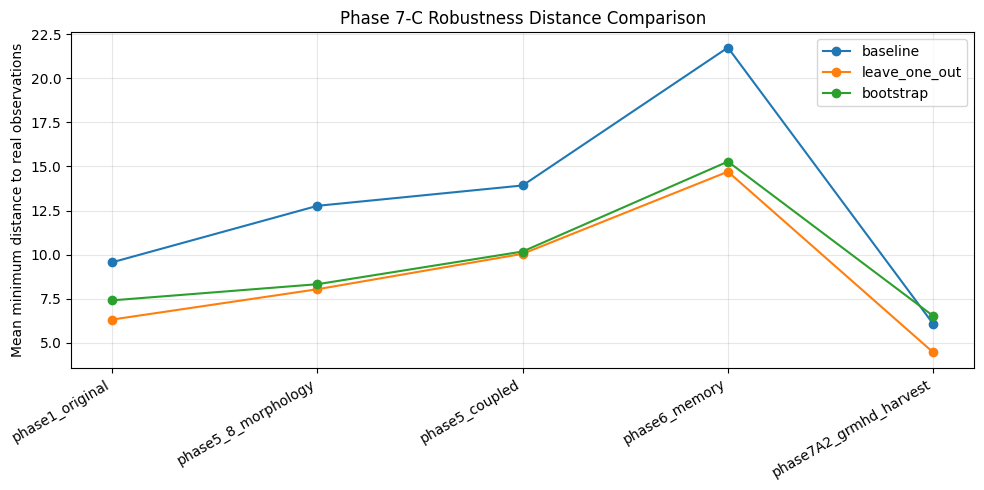

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/figures/phase7C_robustness_distance_comparison.png


In [14]:
# ================================================================
# 14. Figures: distance comparison
# ================================================================

plot_df = robustness_rank_df.copy()

plt.figure(figsize=(10, 5))

for validation in ["baseline", "leave_one_out", "bootstrap"]:
    sub = plot_df[plot_df["validation"] == validation].copy()
    sub = sub.set_index("synthetic_dataset").reindex(REFERENCE_DATASETS).reset_index()

    plt.plot(
        sub["synthetic_dataset"],
        sub["ranking_distance"],
        marker="o",
        label=validation,
    )

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean minimum distance to real observations")
plt.title("Phase 7-C Robustness Distance Comparison")
plt.grid(alpha=0.3)
plt.legend()

distance_plot_path = save_plot(PHASE7C_FIG_DIR / "phase7C_robustness_distance_comparison.png")
print("Saved:", distance_plot_path)

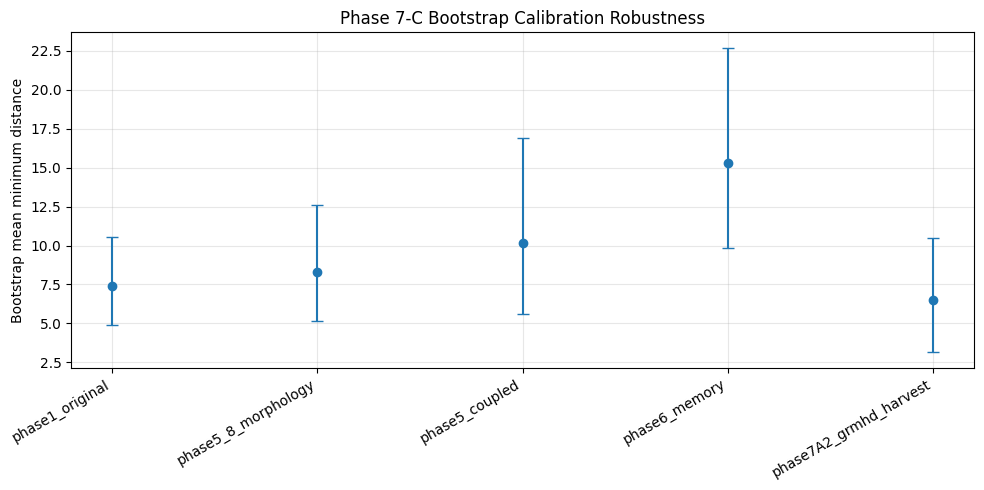

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/figures/phase7C_bootstrap_uncertainty.png


In [15]:
# ================================================================
# 15. Figures: bootstrap uncertainty
# ================================================================

boot_plot = bootstrap_summary_df.set_index("synthetic_dataset").reindex(REFERENCE_DATASETS).reset_index()

x = np.arange(len(boot_plot))
y = boot_plot["bootstrap_mean_min_distance_mean"].to_numpy(dtype=float)
yerr_low = y - boot_plot["bootstrap_mean_min_distance_q05"].to_numpy(dtype=float)
yerr_high = boot_plot["bootstrap_mean_min_distance_q95"].to_numpy(dtype=float) - y

plt.figure(figsize=(10, 5))
plt.errorbar(
    x,
    y,
    yerr=[yerr_low, yerr_high],
    fmt="o",
    capsize=4,
)

plt.xticks(x, boot_plot["synthetic_dataset"], rotation=30, ha="right")
plt.ylabel("Bootstrap mean minimum distance")
plt.title("Phase 7-C Bootstrap Calibration Robustness")
plt.grid(alpha=0.3)

bootstrap_plot_path = save_plot(PHASE7C_FIG_DIR / "phase7C_bootstrap_uncertainty.png")
print("Saved:", bootstrap_plot_path)

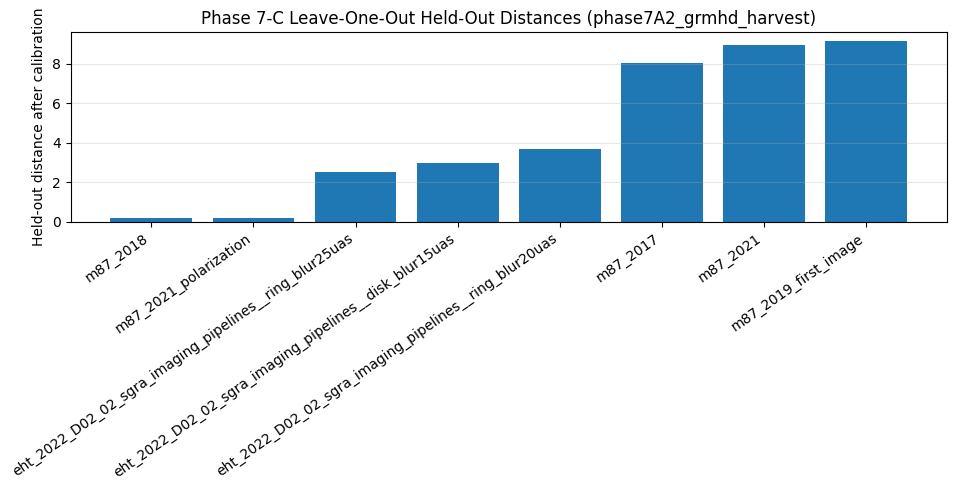

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/figures/phase7C_leave_one_out_bridge_distances.png


In [16]:
# ================================================================
# 16. Figures: LOO per held-out real observation
# ================================================================

loo_bridge_df = loo_df[loo_df["synthetic_dataset"] == BRIDGE_DATASET].copy()
loo_bridge_df = loo_bridge_df.sort_values("mean_min_distance")

plt.figure(figsize=(10, 5))
plt.bar(
    loo_bridge_df["heldout_real_sample_id"],
    loo_bridge_df["mean_min_distance"],
)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out distance after calibration")
plt.title(f"Phase 7-C Leave-One-Out Held-Out Distances ({BRIDGE_DATASET})")
plt.grid(axis="y", alpha=0.3)

loo_plot_path = save_plot(PHASE7C_FIG_DIR / "phase7C_leave_one_out_bridge_distances.png")
print("Saved:", loo_plot_path)

In [17]:
# ================================================================
# 17. Conservative thesis-style interpretation
# ================================================================

def df_to_text(df, max_rows=20):
    if df is None or len(df) == 0:
        return "No data available."
    return df.head(max_rows).to_string(index=False)

phase7c_summary = f"""
# Phase 7-C Summary — Calibration Robustness and Leave-One-Real-Out Validation

## Purpose

Phase 7-C tests whether Phase 7-B synthetic-to-real ridge calibration is robust.

Phase 7-B showed a strong full-fit calibration result, but the real observation set is small.
Therefore, Phase 7-C does not assume that full-fit calibration is reliable.

Instead, it evaluates whether calibration remains meaningful when real observations are held out.

## Inputs

Project root:

{PROJECT_ROOT}

Bridge dataset:

{BRIDGE_DATASET}

Real observations:

{len(real_df)}

Synthetic samples:

{len(synthetic_df)}

Bridge samples:

{len(bridge_df)}

Latent dimensions:

{len(LATENT_COLS)}

Ridge alpha:

{RIDGE_ALPHA}

Pseudo-pair neighbors:

{N_NEIGHBORS}

## Baseline distance summary

{df_to_text(baseline7c_df, max_rows=20)}

## Leave-one-real-out summary

{df_to_text(loo_summary_df, max_rows=20)}

## Full-fit ridge versus leave-one-out comparison

{df_to_text(comparison_loo_df, max_rows=20)}

## Bootstrap robustness summary

{df_to_text(bootstrap_summary_df, max_rows=20)}

## Robustness rankings

{df_to_text(robustness_rank_df, max_rows=30)}

## Robustness criteria

Status:

{robustness_status}

Criteria:

{df_to_text(criteria_df, max_rows=20)}

## Interpretation

If Phase 7-C passes, the calibration bridge is not merely a full-fit artifact.
It suggests that the GRMHD-inspired bridge domain contains reusable latent structure
that can align with held-out real EHT observations.

If Phase 7-C is only a conditional pass, the result is promising but should be stated
as exploratory rather than validated.

If Phase 7-C fails, then Phase 7-B should be interpreted as overfit to the small real
image set, and the next step should be collecting more real or GRMHD-rendered images.

## Conservative conclusion

This phase still does not infer real black-hole histories.

It only evaluates whether calibrated synthetic analogues remain close to real
observations under robustness tests.

A scientifically defensible next step is Phase 7-D:

Calibrated Synthetic Analogue Memory Mapping

That phase should trace robust real-neighbor analogues back to synthetic event families
without claiming direct real-history recovery.
"""

summary_md_path = PHASE7C_REPORT_DIR / "phase7C_calibration_robustness_summary.md"
summary_txt_path = PHASE7C_REPORT_DIR / "phase7C_calibration_robustness_summary.txt"

with open(summary_md_path, "w") as f:
    f.write(phase7c_summary)

with open(summary_txt_path, "w") as f:
    f.write(phase7c_summary)

display(Markdown(phase7c_summary[:4000] + "\n\n..."))

print("Saved:", summary_md_path)
print("Saved:", summary_txt_path)


# Phase 7-C Summary — Calibration Robustness and Leave-One-Real-Out Validation

## Purpose

Phase 7-C tests whether Phase 7-B synthetic-to-real ridge calibration is robust.

Phase 7-B showed a strong full-fit calibration result, but the real observation set is small.
Therefore, Phase 7-C does not assume that full-fit calibration is reliable.

Instead, it evaluates whether calibration remains meaningful when real observations are held out.

## Inputs

Project root:

/home/marwa/files/phase1_blackhole_generator

Bridge dataset:

phase7A2_grmhd_harvest

Real observations:

8

Synthetic samples:

2500

Bridge samples:

500

Latent dimensions:

512

Ridge alpha:

1.0

Pseudo-pair neighbors:

10

## Baseline distance summary

   validation      synthetic_dataset  mean_min_distance  median_min_distance  mean_pairwise_distance  n_real  n_synthetic
full_baseline phase7A2_grmhd_harvest           6.081075             9.280736               27.322515       8          500
full_baseline        phase1_original           9.570396             9.356956               33.040386       8          500
full_baseline    phase5_8_morphology          12.768690            11.367983               25.493828       8          500
full_baseline         phase5_coupled          13.922192            10.436476               35.714207       8          500
full_baseline          phase6_memory          21.732309            14.405910               35.690617       8          500

## Leave-one-real-out summary

     synthetic_dataset  loo_mean_min_distance_mean  loo_mean_min_distance_std  loo_mean_min_distance_median  loo_mean_pairwise_distance_mean  n_heldout_tests
phase7A2_grmhd_harvest                    4.468646                   3.734463                      3.350942                        23.105363                8
       phase1_original                    6.326621                   2.570637                      6.681091                        31.691821                8
   phase5_8_morphology                    8.043867                   4.285543                      8.107162                        21.710656                8
        phase5_coupled                   10.050613                   5.990062                      9.100261                        35.902978                8
         phase6_memory                   14.702864                  10.930256                     10.897249                        34.813477                8

## Full-fit ridge versus leave-one-out comparison

     synthetic_dataset  loo_mean_min_distance_mean  loo_mean_min_distance_std  loo_mean_min_distance_median  loo_mean_pairwise_distance_mean  n_heldout_tests  phase7B_full_ridge_mean_min_distance  phase7B_full_ridge_median_min_distance  phase7B_full_ridge_mean_pairwise_distance  loo_minus_full_ridge_distance  robustness_gap_ratio
phase7A2_grmhd_harvest                    4.468646                   3.734463                      3.350942                        23.105363                8                              0.606323                                0.390717                                  22.790901                       3.862324              7.370078
       phase1_original                    6.326621                   2.570637                      6.681091                        31.691821                8                              4.595303                                4.147371                                  30.936520                       1.731318              1.376758
   phase5_8_morphology                    8.043867                   4.285543                      8.107162                        21.710656                8                              5.955913                                3.785950                                  20.548523                       2.087954              1.350568
        phase5_coupled                   10.050613                   5.990062                      9.100261                        35.902978                8                    

...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/reports/phase7C_calibration_robustness_summary.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/reports/phase7C_calibration_robustness_summary.txt


In [18]:
# ================================================================
# 18. Final index
# ================================================================

phase7c_index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "phase7A_dir": str(PHASE7A_DIR),
    "phase7B_dir": str(PHASE7B_DIR),
    "phase7C_dir": str(PHASE7C_DIR),
    "bridge_dataset": BRIDGE_DATASET,
    "n_real": int(len(real_df)),
    "n_synthetic": int(len(synthetic_df)),
    "n_bridge": int(len(bridge_df)),
    "latent_dimensions": int(len(LATENT_COLS)),
    "n_bootstraps": int(N_BOOTSTRAPS),
    "ridge_alpha": float(RIDGE_ALPHA),
    "n_neighbors": int(N_NEIGHBORS),
    "robustness_status": robustness_status,
    "main_outputs": {
        "baseline": str(baseline7c_path),
        "loo_distances": str(loo_path),
        "loo_summary": str(loo_summary_path),
        "loo_model_info": str(loo_model_path),
        "bootstrap_distances": str(bootstrap_path),
        "bootstrap_summary": str(bootstrap_summary_path),
        "rankings": str(rank_path),
        "criteria": str(criteria_path),
        "summary_md": str(summary_md_path),
        "summary_txt": str(summary_txt_path),
    },
    "figures": {
        "distance_comparison": str(distance_plot_path),
        "bootstrap_uncertainty": str(bootstrap_plot_path),
        "loo_bridge_distances": str(loo_plot_path),
    },
}

index_path = PHASE7C_DIR / "phase7C_index.json"

with open(index_path, "w") as f:
    json.dump(phase7c_index, f, indent=2)

print("=" * 80)
print("Phase 7-C complete")
print("=" * 80)
print("Robustness status:", robustness_status)
print("Index:", index_path)
print("Output directory:", PHASE7C_DIR)
print("Tables:", PHASE7C_TABLE_DIR)
print("Figures:", PHASE7C_FIG_DIR)
print("Reports:", PHASE7C_REPORT_DIR)
print("=" * 80)

Phase 7-C complete
Robustness status: CONDITIONAL_PASS
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/phase7C_index.json
Output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/reports
